<div align="right">
  <font color="#00796B" size="4"><b>
  TEAM 우리터빈이달라졌어요
  </b></font>
</div>

# 풍력 발전기 스마트 예방 정비 시스템 구축

이 노트북은 풍력 발전기 표면 이미지 데이터셋을 사용하여 Object Detection 모델을 만들기 위해 수행한 EDA의 최종 제출용 노트북이다. 

### 데이터셋 
- Ajifoster3, "YOLO Annotated Wind Turbine Surface Damage", <i>kaggle</i>
    - https://www.kaggle.com/datasets/ajifoster3/yolo-annotated-wind-turbines-586x371


# 한글 폰트 설정

motplotlib 실행 시 한글이 깨지는 현상에 대한 대비.

In [ ]:
# 나눔고딕 폰트 설치
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm -rf ~/.cache/matplotlib

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 3 not upgraded.
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory detected
/usr/share/fonts/truetype/liberation: skipping, looped directory detected
/usr/share/fonts/truetype/n

In [ ]:
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt

font_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"
font_name = fm.FontProperties(fname=font_path).get_name()
plt.rc("font", family=font_name)
plt.rcParams["axes.unicode_minus"] = False  # 마이너스 기호 깨짐 방지

print("적용된 폰트:", font_name)

적용된 폰트: NanumGothic


# 라이브러리 로드

In [ ]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from collections import Counter
from tqdm import tqdm

# 0. 경로 설정

In [ ]:
BASE_DIR = "/content/drive/MyDrive/yolo-annotated-wind-turbines/NordTank586x371"
IMG_DIR = os.path.join(BASE_DIR, "images")
LBL_DIR = os.path.join(BASE_DIR, "labels")

CLASS_NAMES = {0: "Dirt", 1: "Damage"}  # data.yaml / classes.txt 확인 후 실제 매핑으로 수정

# 1. EDA 수행 함수 정의

In [ ]:
# ============================================================
# 1. 이미지-라벨 매칭 점검
# ============================================================
def check_image_label_matching():
    img_files = glob.glob(os.path.join(IMG_DIR, "*.png")) + glob.glob(os.path.join(IMG_DIR, "*.jpg"))
    lbl_files = glob.glob(os.path.join(LBL_DIR, "*.txt"))

    img_stems = set(os.path.splitext(os.path.basename(f))[0] for f in img_files)
    lbl_stems = set(os.path.splitext(os.path.basename(f))[0] for f in lbl_files)

    only_img = img_stems - lbl_stems   # 라벨 없는 이미지 (background or 누락)
    only_lbl = lbl_stems - img_stems   # 이미지 없는 라벨 (오류)

    print(f"이미지 총 개수: {len(img_stems)}")
    print(f"라벨 총 개수: {len(lbl_stems)}")
    print(f"라벨 없는 이미지 수: {len(only_img)}")
    print(f"이미지 없는 라벨 수: {len(only_lbl)}")

    if only_img:
        print("  -> 라벨 없는 이미지 예시:", list(only_img)[:5])
    if only_lbl:
        print("  -> 이미지 없는 라벨 예시:", list(only_lbl)[:5])

    return img_stems, lbl_stems, only_img, only_lbl



In [ ]:
# ============================================================
# 2. 전체 어노테이션 파싱 -> 하나의 DataFrame으로
# ============================================================
def parse_all_annotations():
    rows = []
    lbl_files = glob.glob(os.path.join(LBL_DIR, "*.txt"))

    for lbl_path in tqdm(lbl_files, desc="어노테이션 파싱 중"):
        stem = os.path.splitext(os.path.basename(lbl_path))[0]

        # 매칭되는 이미지 찾기 (png/jpg 둘 다 시도)
        img_path_png = os.path.join(IMG_DIR, stem + ".png")
        img_path_jpg = os.path.join(IMG_DIR, stem + ".jpg")
        img_path = img_path_png if os.path.exists(img_path_png) else img_path_jpg

        if not os.path.exists(img_path):
            continue  # 이미지 없는 라벨은 스킵 (위에서 이미 체크됨)

        img = cv2.imread(img_path)
        if img is None:
            continue
        h, w = img.shape[:2]

        with open(lbl_path, "r") as f:
            lines = f.readlines()

        if len(lines) == 0:
            # 빈 라벨 파일 (객체 없음, background로 라벨링된 경우)
            rows.append({
                "stem": stem, "img_path": img_path, "img_w": w, "img_h": h,
                "class_id": None, "x_center": None, "y_center": None,
                "bbox_w_norm": None, "bbox_h_norm": None
            })
            continue

        for line in lines:
            parts = line.strip().split()
            if len(parts) != 5:
                print(f"[경고] 형식 오류 라인 발견: {lbl_path} -> {line}")
                continue
            cls, xc, yc, bw, bh = parts
            rows.append({
                "stem": stem, "img_path": img_path, "img_w": w, "img_h": h,
                "class_id": int(cls), "x_center": float(xc), "y_center": float(yc),
                "bbox_w_norm": float(bw), "bbox_h_norm": float(bh)
            })

    df = pd.DataFrame(rows)

    # 픽셀 단위 환산
    df["bbox_w_px"] = df["bbox_w_norm"] * df["img_w"]
    df["bbox_h_px"] = df["bbox_h_norm"] * df["img_h"]
    df["bbox_area_px"] = df["bbox_w_px"] * df["bbox_h_px"]
    df["bbox_area_ratio"] = df["bbox_w_norm"] * df["bbox_h_norm"]  # 이미지 대비 면적 비율
    df["aspect_ratio"] = df["bbox_w_px"] / df["bbox_h_px"]
    df["class_name"] = df["class_id"].map(CLASS_NAMES)

    return df

In [ ]:
# ============================================================
# 2-1. 정상(Normal) vs 이상(Anomaly: Dirt/Damage 존재) 이미지 비율 분석
#   - 라벨 파일이 없거나 비어있는 이미지 = 정상 블레이드 (negative sample)
#   - 라벨 파일에 객체가 1개 이상 = 이상 블레이드
# ============================================================
def analyze_normal_vs_anomaly():
    img_files = glob.glob(os.path.join(IMG_DIR, "*.png")) + glob.glob(os.path.join(IMG_DIR, "*.jpg"))
    normal, anomaly = [], []

    for img_path in img_files:
        stem = os.path.splitext(os.path.basename(img_path))[0]
        lbl_path = os.path.join(LBL_DIR, stem + ".txt")

        if not os.path.exists(lbl_path):
            normal.append(stem)
        else:
            with open(lbl_path, "r") as f:
                lines = [l for l in f.readlines() if l.strip()]
            if len(lines) == 0:
                normal.append(stem)
            else:
                anomaly.append(stem)

    n_total = len(img_files)
    print(f"전체 이미지 수: {n_total}")
    print(f"정상(라벨 없음) 이미지: {len(normal)}개 ({len(normal)/n_total:.1%})")
    print(f"이상(Dirt/Damage 존재) 이미지: {len(anomaly)}개 ({len(anomaly)/n_total:.1%})")

    plt.figure(figsize=(5, 4))
    plt.bar(["정상", "이상(Dirt/Damage)"], [len(normal), len(anomaly)], color=["#4C72B0", "#C44E52"])
    plt.title("정상 vs 이상 이미지 비율")
    plt.ylabel("이미지 수")
    plt.tight_layout()
    plt.savefig("/content/eda_normal_vs_anomaly.png", dpi=150)
    plt.show()

    return normal, anomaly

In [ ]:
# ============================================================
# 2-2. (속도 개선) 이미지 해상도가 고정인 경우 사용하는 빠른 파싱
#   폴더명이 NordTank586x371 이므로 전부 586x371일 가능성이 높음.
#   먼저 fixed_size 가정이 맞는지 소규모 샘플로 검증한 뒤 사용할 것.
# ============================================================
def verify_fixed_resolution(sample_n=30):
    img_files = (glob.glob(os.path.join(IMG_DIR, "*.png")) +
                 glob.glob(os.path.join(IMG_DIR, "*.jpg")))
    sample = img_files[:sample_n]
    sizes = set()
    for p in sample:
        img = cv2.imread(p)
        if img is not None:
            sizes.add(img.shape[:2])  # (h, w)
    print(f"샘플 {len(sample)}장 중 발견된 해상도 종류: {sizes}")
    return sizes


def parse_all_annotations_fast(fixed_w=586, fixed_h=371):
    """이미지 해상도가 고정값이라고 확신할 때만 사용 (cv2.imread 생략 -> 훨씬 빠름)"""
    rows = []
    lbl_files = glob.glob(os.path.join(LBL_DIR, "*.txt"))

    for lbl_path in tqdm(lbl_files, desc="어노테이션 파싱 중 (fast)"):
        stem = os.path.splitext(os.path.basename(lbl_path))[0]

        img_path_png = os.path.join(IMG_DIR, stem + ".png")
        img_path_jpg = os.path.join(IMG_DIR, stem + ".jpg")
        img_path = img_path_png if os.path.exists(img_path_png) else img_path_jpg

        if not os.path.exists(img_path):
            continue

        w, h = fixed_w, fixed_h  # imread 없이 고정값 사용

        with open(lbl_path, "r") as f:
            lines = f.readlines()

        if len(lines) == 0:
            rows.append({
                "stem": stem, "img_path": img_path, "img_w": w, "img_h": h,
                "class_id": None, "x_center": None, "y_center": None,
                "bbox_w_norm": None, "bbox_h_norm": None
            })
            continue

        for line in lines:
            parts = line.strip().split()
            if len(parts) != 5:
                print(f"[경고] 형식 오류 라인 발견: {lbl_path} -> {line}")
                continue
            cls, xc, yc, bw, bh = parts
            rows.append({
                "stem": stem, "img_path": img_path, "img_w": w, "img_h": h,
                "class_id": int(cls), "x_center": float(xc), "y_center": float(yc),
                "bbox_w_norm": float(bw), "bbox_h_norm": float(bh)
            })

    df = pd.DataFrame(rows)
    df["bbox_w_px"] = df["bbox_w_norm"] * df["img_w"]
    df["bbox_h_px"] = df["bbox_h_norm"] * df["img_h"]
    df["bbox_area_px"] = df["bbox_w_px"] * df["bbox_h_px"]
    df["bbox_area_ratio"] = df["bbox_w_norm"] * df["bbox_h_norm"]
    df["aspect_ratio"] = df["bbox_w_px"] / df["bbox_h_px"]
    df["class_name"] = df["class_id"].map(CLASS_NAMES)

    return df

In [ ]:
# ============================================================
# 3. 기본 통계
# ============================================================
def basic_stats(df):
    n_images = df["stem"].nunique()
    n_objects = df["class_id"].notna().sum()
    n_empty = df[df["class_id"].isna()]["stem"].nunique()

    print(f"총 이미지 수: {n_images}")
    print(f"총 객체(bbox) 수: {n_objects}")
    print(f"객체 없는(empty) 이미지 수: {n_empty}")
    print(f"이미지당 평균 객체 수: {n_objects / n_images:.2f}")
    print()
    print("클래스별 객체 수:")
    print(df["class_name"].value_counts())

    # 이미지당 객체 수 분포
    objs_per_image = df.groupby("stem")["class_id"].apply(lambda x: x.notna().sum())
    print()
    print("이미지당 객체 수 분포:")
    print(objs_per_image.describe())

    return objs_per_image

In [ ]:
# ============================================================
# 4. 클래스 불균형 시각화
# ============================================================
def plot_class_distribution(df):
    plt.figure(figsize=(6, 4))
    sns.countplot(data=df[df["class_id"].notna()], x="class_name")
    plt.title("클래스별 객체 수 (Dirt vs Damage)")
    plt.xlabel("Class")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.savefig("/content/eda_class_distribution.png", dpi=150)
    plt.show()

In [ ]:
# ============================================================
# 5. bbox 크기 분포 (절대 px 기준 + 면적 비율 기준)
# ============================================================
def plot_bbox_size_distribution(df):
    valid = df[df["class_id"].notna()]

    fig, axes = plt.subplots(2, 2, figsize=(12, 8))

    sns.histplot(data=valid, x="bbox_w_px", hue="class_name", bins=40, ax=axes[0, 0])
    axes[0, 0].set_title("Bounding Box Width (px)")

    sns.histplot(data=valid, x="bbox_h_px", hue="class_name", bins=40, ax=axes[0, 1])
    axes[0, 1].set_title("Bounding Box Height (px)")

    sns.histplot(data=valid, x="bbox_area_ratio", hue="class_name", bins=40, ax=axes[1, 0])
    axes[1, 0].set_title("이미지 대비 면적 비율")
    axes[1, 0].set_xlim(0, valid["bbox_area_ratio"].quantile(0.99))  # 극단치 제외하고 보기

    sns.histplot(data=valid, x="aspect_ratio", hue="class_name", bins=40, ax=axes[1, 1])
    axes[1, 1].set_title("종횡비 (W/H)")
    axes[1, 1].set_xlim(0, valid["aspect_ratio"].quantile(0.99))

    plt.tight_layout()
    plt.savefig("/content/eda_bbox_size.png", dpi=150)
    plt.show()

    # small object 비율 (COCO 기준: area < 32*32px = small)
    small_ratio = (valid["bbox_area_px"] < 32 * 32).mean()
    print(f"COCO 기준 'small object'(32x32px 미만) 비율: {small_ratio:.1%}")

In [ ]:
# ============================================================
# 6. bbox 위치 히트맵 (이미지 내 어디에 주로 위치하는지)
# ============================================================
def plot_bbox_location_heatmap(df):
    valid = df[df["class_id"].notna()]

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    for ax, (cls_id, cls_name) in zip(axes, CLASS_NAMES.items()):
        subset = valid[valid["class_id"] == cls_id]
        ax.hist2d(subset["x_center"], subset["y_center"], bins=30, cmap="viridis")
        ax.set_title(f"{cls_name} 위치 분포 (정규화 좌표)")
        ax.set_xlabel("x_center")
        ax.set_ylabel("y_center")
        ax.invert_yaxis()  # 이미지 좌표계에 맞춰 위->아래

    plt.tight_layout()
    plt.savefig("/content/eda_location_heatmap.png", dpi=150)
    plt.show()

In [ ]:
# ============================================================
# 7. 샘플 이미지에 bbox 그려서 육안 검수
# ============================================================
def visualize_samples(df, n_samples=9):
    sample_stems = df[df["class_id"].notna()]["stem"].drop_duplicates().sample(
        min(n_samples, df["stem"].nunique()), random_state=42
    )

    fig, axes = plt.subplots(3, 3, figsize=(15, 12))
    axes = axes.flatten()

    colors = {0: (0, 255, 0), 1: (0, 0, 255)}  # Dirt=초록, Damage=빨강 (BGR)

    for ax, stem in zip(axes, sample_stems):
        sub = df[df["stem"] == stem]
        img = cv2.imread(sub.iloc[0]["img_path"])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        h, w = img.shape[:2]

        for _, row in sub.iterrows():
            if pd.isna(row["class_id"]):
                continue
            xc, yc = row["x_center"] * w, row["y_center"] * h
            bw, bh = row["bbox_w_norm"] * w, row["bbox_h_norm"] * h
            x1, y1 = int(xc - bw / 2), int(yc - bh / 2)
            x2, y2 = int(xc + bw / 2), int(yc + bh / 2)
            color = colors.get(int(row["class_id"]), (255, 255, 0))
            cv2.rectangle(img, (x1, y1), (x2, y2), color, 1)

        ax.imshow(img)
        ax.set_title(stem, fontsize=8)
        ax.axis("off")

    plt.tight_layout()
    plt.savefig("/content/eda_sample_visualization.png", dpi=150)
    plt.show()

In [ ]:
# ============================================================
# 8. 이미지 품질 (밝기/블러) 분석
# ============================================================
def analyze_image_quality(df, sample_n=None):
    stems = df["stem"].drop_duplicates()
    if sample_n:
        stems = stems.sample(min(sample_n, len(stems)), random_state=42)

    results = []
    for stem in stems:
        img_path = df[df["stem"] == stem].iloc[0]["img_path"]
        img = cv2.imread(img_path)
        if img is None:
            continue
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        brightness = gray.mean()
        blur_score = cv2.Laplacian(gray, cv2.CV_64F).var()  # 낮을수록 blur 심함
        results.append({"stem": stem, "brightness": brightness, "blur_score": blur_score})

    quality_df = pd.DataFrame(results)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    sns.histplot(quality_df["brightness"], bins=30, ax=axes[0])
    axes[0].set_title("밝기(brightness) 분포")
    sns.histplot(quality_df["blur_score"], bins=30, ax=axes[1])
    axes[1].set_title("선명도(Laplacian variance) 분포 - 낮을수록 blur")
    plt.tight_layout()
    plt.savefig("/content/eda_image_quality.png", dpi=150)
    plt.show()

    return quality_df


In [ ]:
# ============================================================
# 9. 클래스 공존 (한 이미지에 Dirt+Damage 동시 등장 비율)
# ============================================================
def class_cooccurrence(df):
    valid = df[df["class_id"].notna()]
    per_image_classes = valid.groupby("stem")["class_id"].apply(set)

    both = per_image_classes.apply(lambda s: {0, 1}.issubset(s)).sum()
    only_dirt = per_image_classes.apply(lambda s: s == {0}).sum()
    only_damage = per_image_classes.apply(lambda s: s == {1}).sum()

    print(f"Dirt+Damage 동시 등장 이미지: {both}")
    print(f"Dirt만 있는 이미지: {only_dirt}")
    print(f"Damage만 있는 이미지: {only_damage}")

# 2. EDA 수행

In [ ]:
# 사진 해상도 확인
verify_fixed_resolution(sample_n=50)

샘플 50장 중 발견된 해상도 종류: {(371, 586)}


{(371, 586)}

## 2-1.  어노테이션(객체) 파싱

In [ ]:
# 어노테이션(객체) 파싱
df = parse_all_annotations_fast(fixed_w=586, fixed_h=371)
print(df.shape)
df.head()

어노테이션 파싱 중 (fast): 100%|██████████| 2996/2996 [00:34<00:00, 86.25it/s] 


(9351, 15)


,stem,img_path,img_w,img_h,class_id,x_center,y_center,bbox_w_norm,bbox_h_norm,bbox_w_px,bbox_h_px,bbox_area_px,bbox_area_ratio,aspect_ratio,class_name
0,DJI_0361_07_08,/content/drive/MyDrive/yolo-annotated-wind-tur...,586,371,1,0.733788,0.136119,0.010239,0.035040,6.000054,12.999840,77.999742,0.000359,0.461548,Damage
1,DJI_0361_07_08,/content/drive/MyDrive/yolo-annotated-wind-tur...,586,371,1,0.947099,0.191375,0.010239,0.026954,6.000054,9.999934,60.000144,0.000276,0.600009,Damage
2,DJI_0376_08_09,/content/drive/MyDrive/yolo-annotated-wind-tur...,586,371,1,0.308020,0.032345,0.090444,0.064690,53.000184,23.999990,1272.003886,0.005851,2.208342,Damage
3,DJI_0376_08_09,/content/drive/MyDrive/yolo-annotated-wind-tur...,586,371,1,0.351536,0.016173,0.027304,0.032345,16.000144,11.999995,192.001648,0.000883,1.333346,Damage
4,DJI_0376_08_09,/content/drive/MyDrive/yolo-annotated-wind-tur...,586,371,1,0.392491,0.013477,0.027304,0.026954,16.000144,9.999934,160.000384,0.000736,1.600025,Damage


## 2-2. 기본 통계

In [ ]:
# 기본 통계
objs_per_image = basic_stats(df)

총 이미지 수: 2995
총 객체(bbox) 수: 9351
객체 없는(empty) 이미지 수: 0
이미지당 평균 객체 수: 3.12

클래스별 객체 수:
class_name
Damage    8770
Dirt       581
Name: count, dtype: int64

이미지당 객체 수 분포:
count    2995.000000
mean        3.122204
std         3.422063
min         1.000000
25%         1.000000
50%         2.000000
75%         4.000000
max        37.000000
Name: class_id, dtype: float64


## 2-3. 정상 vs 비정상 이미지 비율 분석

전체 이미지 수: 13470
정상(라벨 없음) 이미지: 10475개 (77.8%)
이상(Dirt/Damage 존재) 이미지: 2995개 (22.2%)


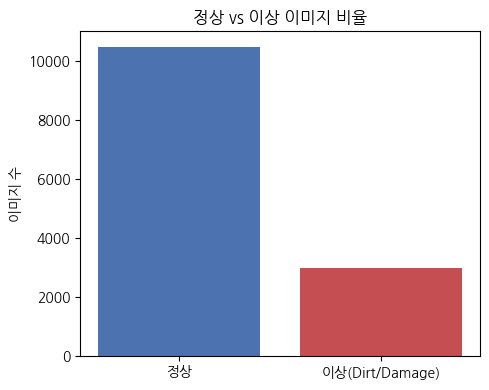

In [ ]:
# 정상 vs 비정상 이미지 비율 분석
normal, anomaly = analyze_normal_vs_anomaly()

## 2-4. 클래스 불균형 확인

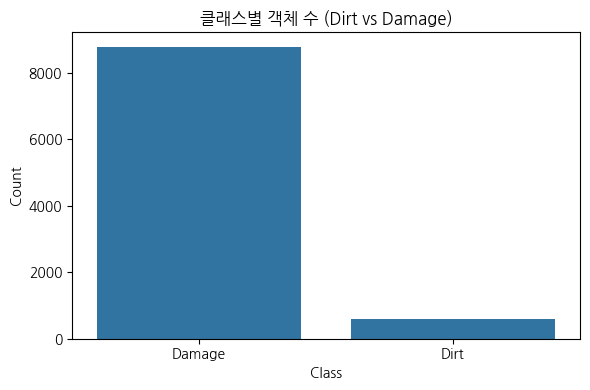

In [ ]:
# 클래스 불균형 확인
plot_class_distribution(df)

## 2-5 B-box 사이즈 분석 및 위치 히트맵

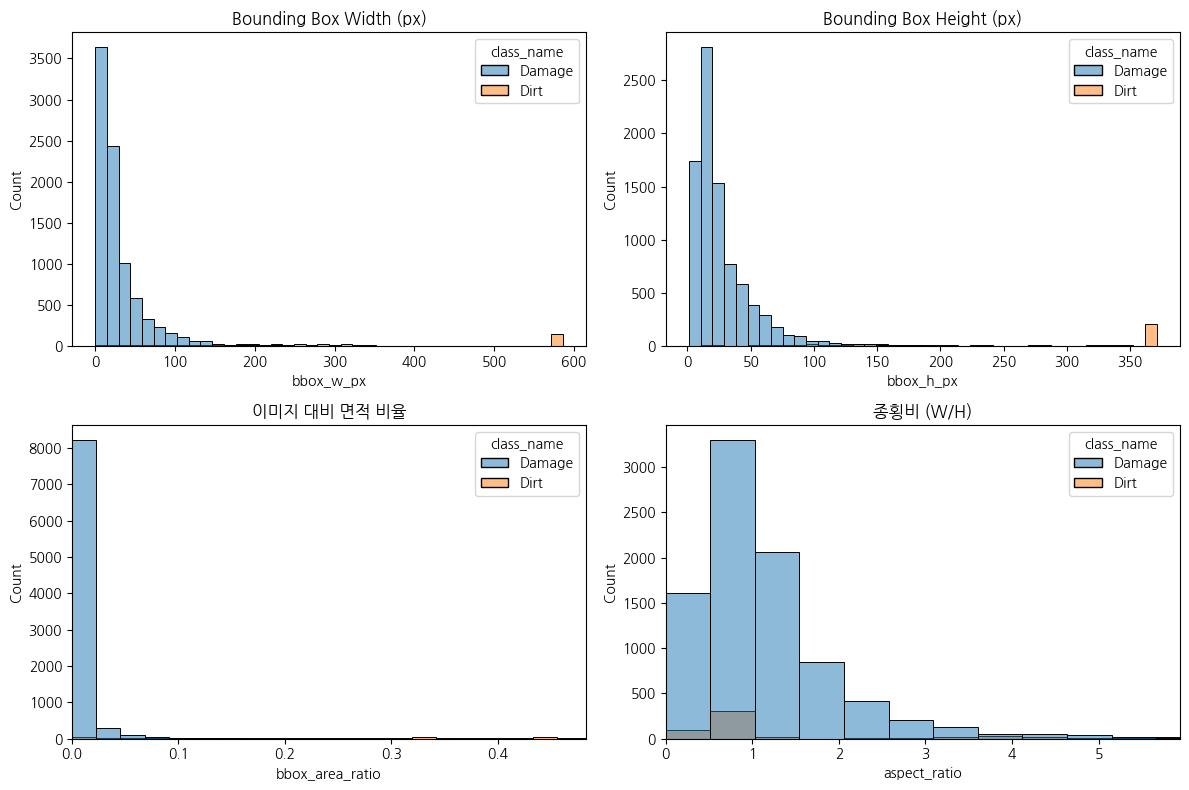

COCO 기준 'small object'(32x32px 미만) 비율: 69.3%


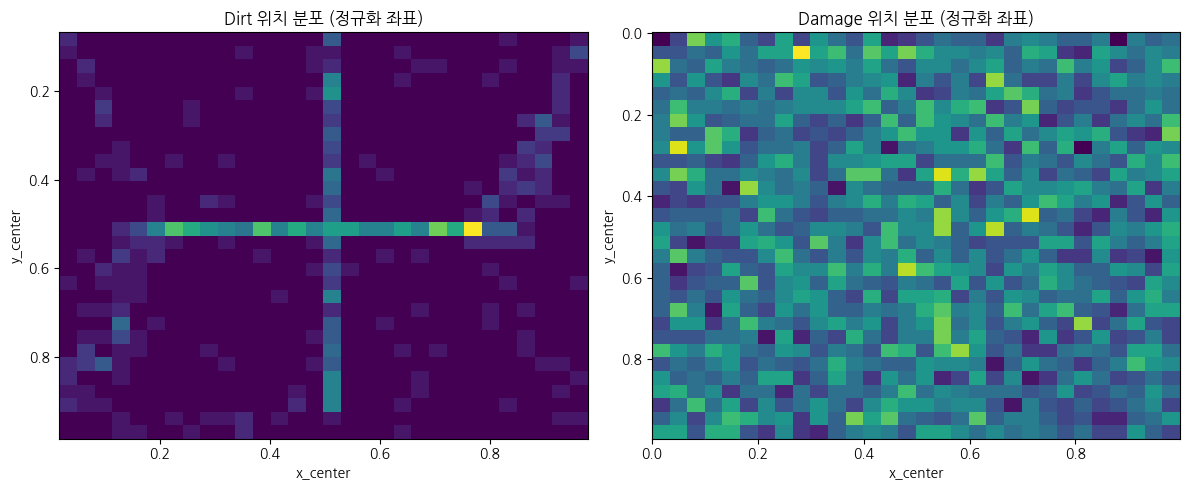

In [ ]:
# B-box 사이즈 분석 및 위치 히트맵
plot_bbox_size_distribution(df)
plot_bbox_location_heatmap(df)

Dirt class의 B-box 크기가 일부 비정삭적으로 큰 것이 포착되었다.   
이상치인지를 확인하기 위해서 샘플을 따로 뽑아서 확인하였다.

                stem class_name  bbox_area_ratio
32    DJI_0693_07_05       Dirt         0.525597
44    DJI_0630_05_05       Dirt         0.389078
55    DJI_0701_05_05       Dirt         0.342907
80    DJI_0743_02_01       Dirt         0.347709
98    DJI_0744_03_01       Dirt         0.544474
...              ...        ...              ...
9178  DJI_0744_03_03       Dirt         0.307278
9190  DJI_0624_08_05       Dirt         0.539249
9278  DJI_0587_01_04       Dirt         0.339590
9328  DJI_0585_01_03       Dirt         0.346416
9343  DJI_0632_07_03       Dirt         0.496587

[334 rows x 3 columns]


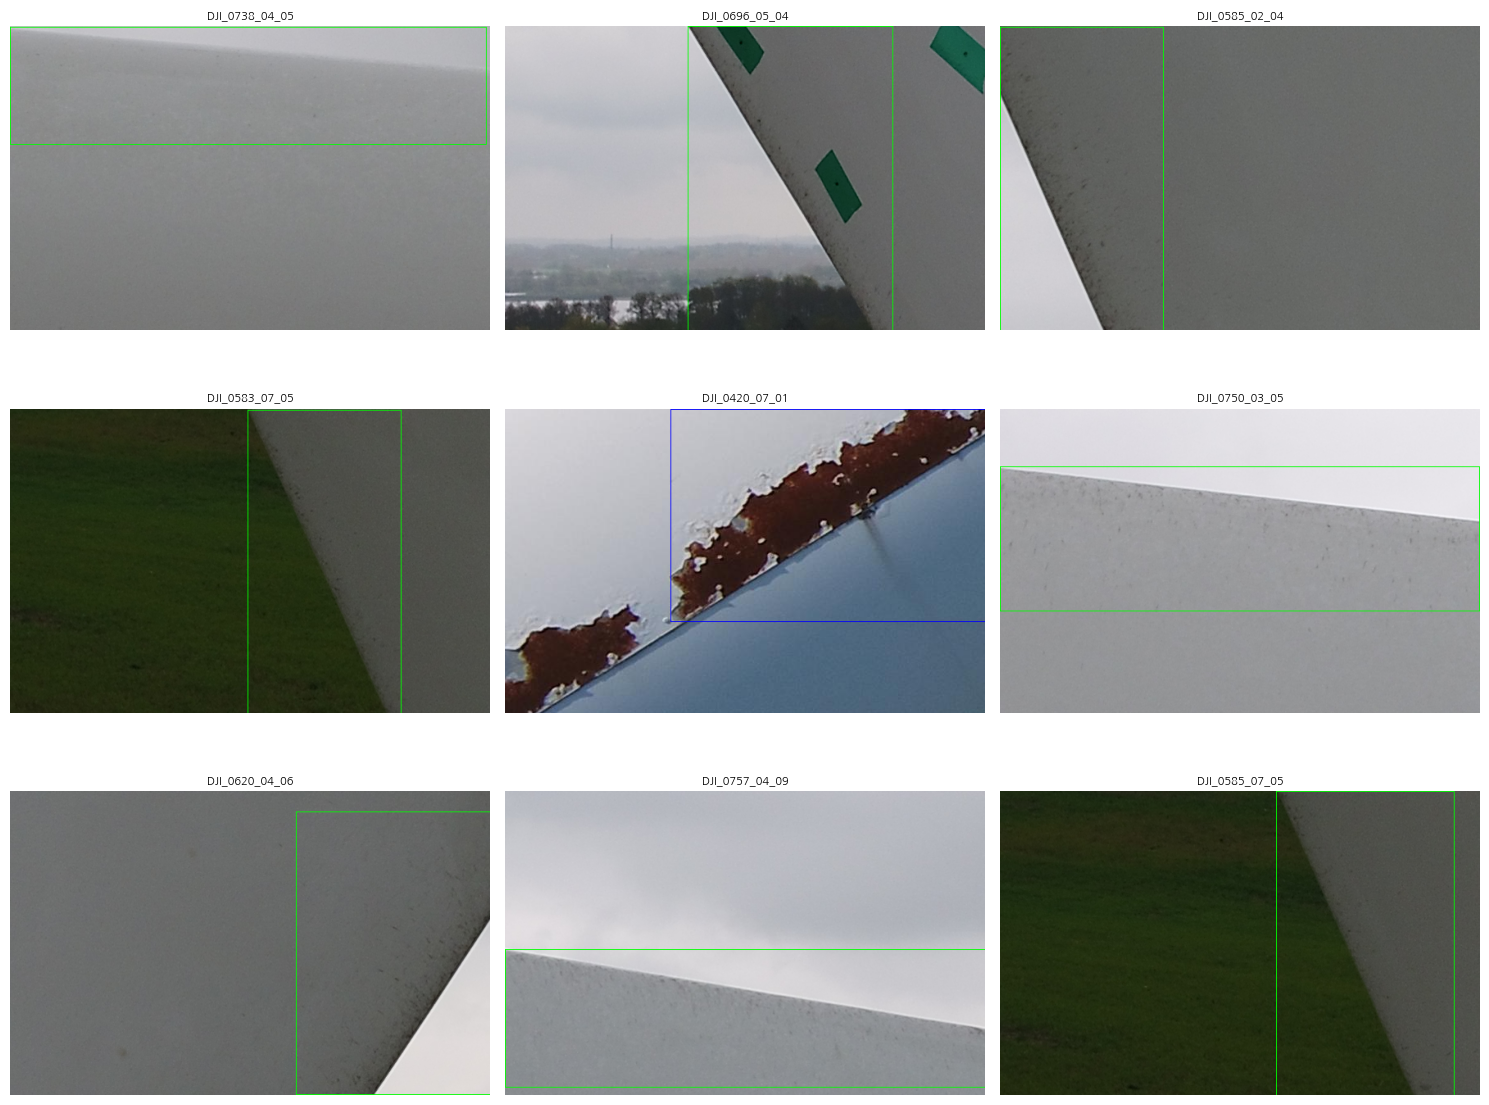

In [ ]:
outliers = df[df["bbox_area_ratio"] > 0.3]
print(outliers[["stem", "class_name", "bbox_area_ratio"]])
visualize_samples(outliers, n_samples=min(9, len(outliers)))

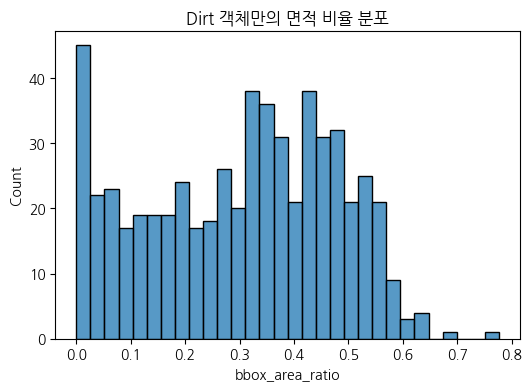

count    581.000000
mean       0.302186
std        0.173808
min        0.000166
25%        0.157641
50%        0.324232
75%        0.440517
max        0.776451
Name: bbox_area_ratio, dtype: float64


In [ ]:
# dirt class 분포 따로 확인
dirt_df = df[df["class_name"] == "Dirt"]
plt.figure(figsize=(6,4))
sns.histplot(dirt_df["bbox_area_ratio"], bins=30)
plt.title("Dirt 객체만의 면적 비율 분포")
plt.show()

print(dirt_df["bbox_area_ratio"].describe())

## 2-6. 샘플 시각화

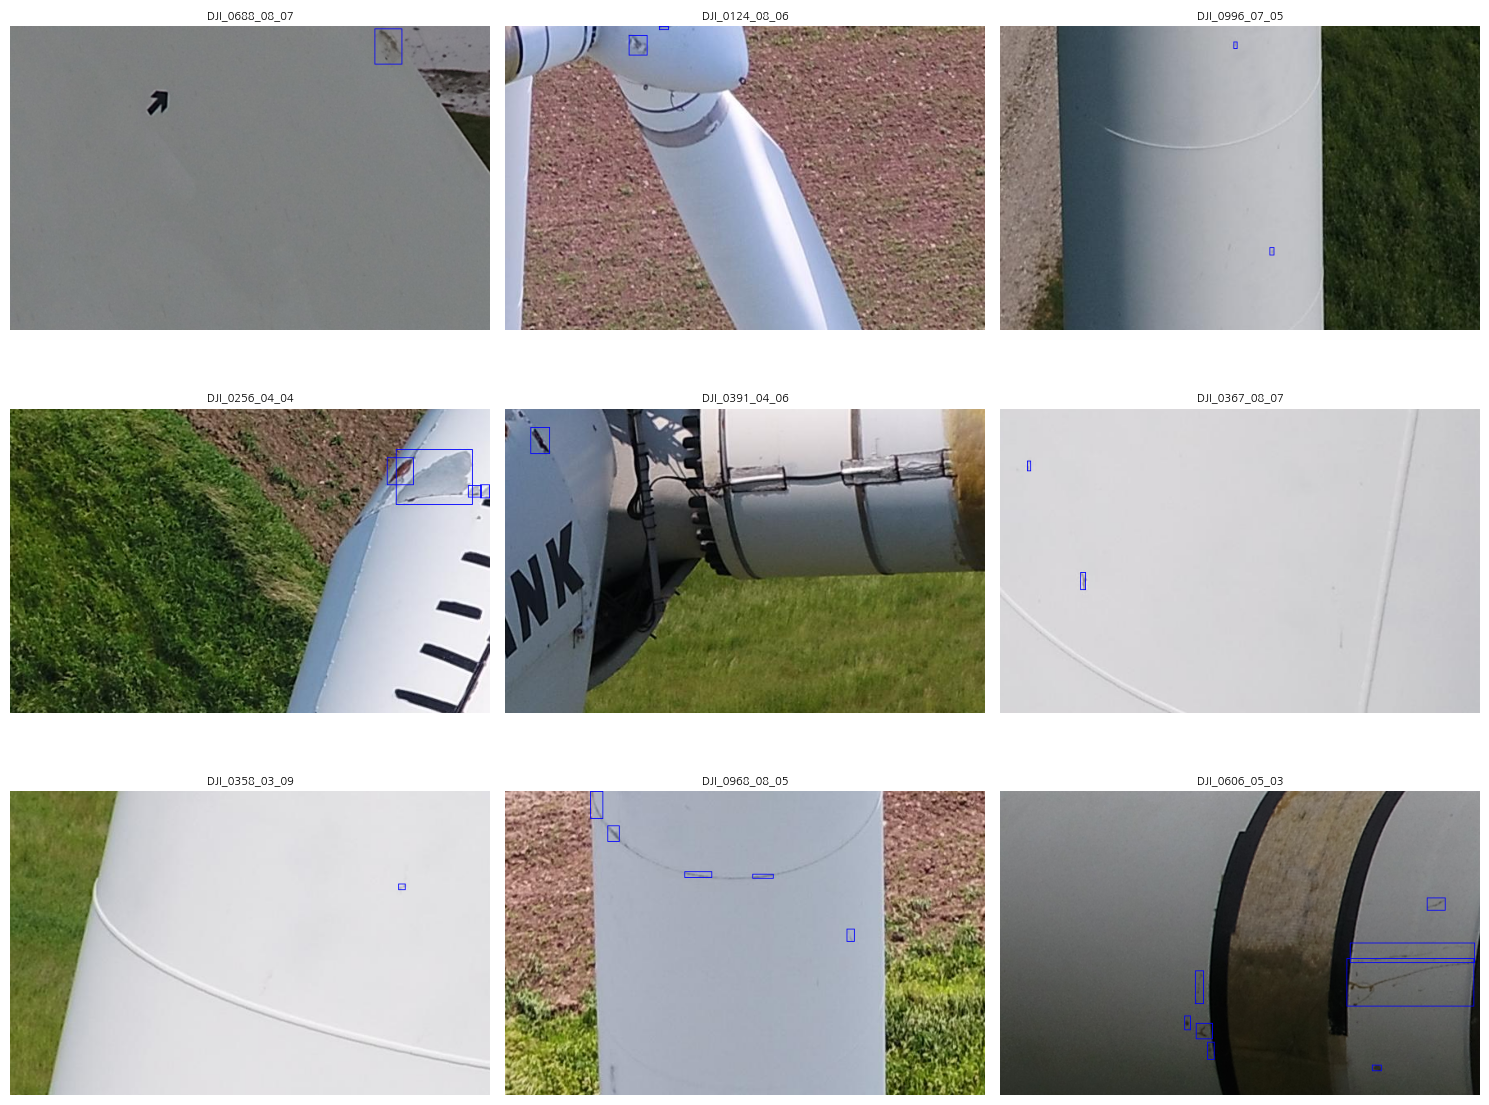

In [ ]:
# 샘플 시각화
visualize_samples(df)

## 2-7. 이미지 품질 분석

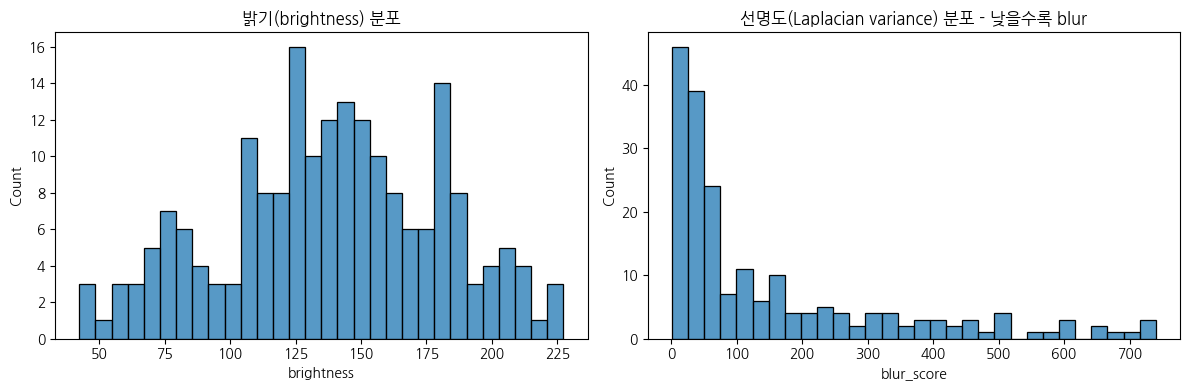

,stem,brightness,blur_score
0,DJI_0688_08_07,125.871632,37.771777
1,DJI_0124_08_06,136.302016,599.382289
2,DJI_0996_07_05,107.183026,110.618849
3,DJI_0256_04_04,105.628267,686.870319
4,DJI_0391_04_06,99.942265,252.000251
...,...,...,...
195,DJI_0753_04_02,132.439854,18.153293
196,DJI_0105_06_04,154.391815,596.681333
197,DJI_0186_03_05,118.971243,312.114946
198,DJI_0011_03_05,129.327861,494.591293


In [ ]:
# 이미지 품질 분석
analyze_image_quality(df, sample_n=200)

In [ ]:
import random

# 정상 이미지에서도 200장 샘플링해서 blur 측정
normal_sample = random.sample(normal, min(200, len(normal)))

normal_quality = []
for stem in normal_sample:
    img_path_png = os.path.join(IMG_DIR, stem + ".png")
    img_path_jpg = os.path.join(IMG_DIR, stem + ".jpg")
    img_path = img_path_png if os.path.exists(img_path_png) else img_path_jpg
    img = cv2.imread(img_path)
    if img is None:
        continue
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    brightness = gray.mean()
    blur_score = cv2.Laplacian(gray, cv2.CV_64F).var()
    normal_quality.append({"stem": stem, "brightness": brightness, "blur_score": blur_score, "has_label": False})

normal_quality_df = pd.DataFrame(normal_quality)

# 이상 이미지 quality_df와 합치기
anomaly_quality_df = quality_df.copy()
anomaly_quality_df["has_label"] = True

combined = pd.concat([normal_quality_df, anomaly_quality_df[["stem","brightness","blur_score","has_label"]]])
print(combined.groupby("has_label")["blur_score"].describe())
print(combined.groupby("has_label")["brightness"].describe())

           count        mean         std       min        25%        50%  \
has_label                                                                  
False      200.0  281.250254  417.347294  4.017258  28.167077  96.177816   
True       200.0  152.111919  180.715102  1.194645  27.435926  63.314133   

                  75%          max  
has_label                           
False      382.811647  2680.374073  
True       210.015416   739.976933  
           count        mean        std        min         25%         50%  \
has_label                                                                    
False      200.0  123.691572  34.690034  28.376954  101.266194  124.972765   
True       200.0  138.272076  41.685878  42.425370  111.271609  139.476047   

                  75%         max  
has_label                          
False      147.000749  217.329687  
True       170.573242  227.249073  


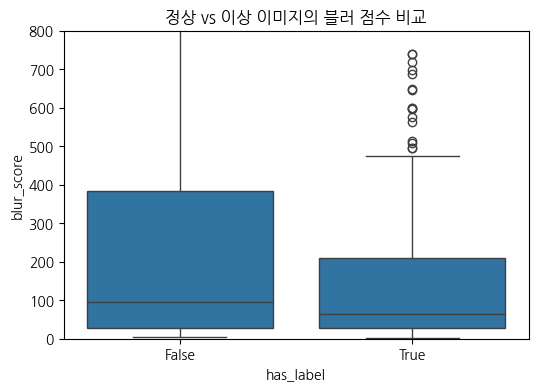

In [ ]:
plt.figure(figsize=(6,4))
sns.boxplot(data=combined, x="has_label", y="blur_score")
plt.title("정상 vs 이상 이미지의 블러 점수 비교")
plt.ylim(0, 800)  # 극단치 제외하고 보기
plt.show()

## 2-8. 클래스 공존 분석

In [ ]:
# 클래스 공존 분석
class_cooccurrence(df)

Dirt+Damage 동시 등장 이미지: 95
Dirt만 있는 이미지: 468
Damage만 있는 이미지: 2432


# 3. 풍력 터빈 블레이드 손상 탐지 데이터셋 EDA 요약 리포트

**데이터셋**: NordTank586x371 (YOLO 포맷, Dirt/Damage 2-class)<br>
**전체 이미지 수**: 13,470장 (해상도 586×371 고정)

---

## 1. 데이터 기본 현황

전체 13,470장 중 라벨이 존재하는(이상이 발견된) 이미지는 2,995장(22.2%), 라벨이 없는(정상) 이미지는 10,475장(77.8%)이다. 이상 이미지 2,995장에서 총 9,351개의 객체가 탐지되었으며, 이미지당 평균 객체 수는 3.12개다(중앙값 2개, 최댓값 37개로 일부 이미지에 객체가 몰려있는 long-tail 분포).

| 구분 | 수치 |
|---|---|
| 전체 이미지 | 13,470장 |
| 정상 이미지 (라벨 없음) | 10,475장 (77.8%) |
| 이상 이미지 (라벨 있음) | 2,995장 (22.2%) |
| 전체 객체(bbox) 수 | 9,351개 |
| 이미지당 평균 객체 수 | 3.12개 (중앙값 2개) |

## 2. 클래스 불균형

Damage와 Dirt 클래스 간 불균형이 매우 심각하다. Damage가 8,770개(93.8%), Dirt가 581개(6.2%)로 약 15:1 비율이다. 이 정도 불균형은 모델이 Dirt 클래스를 충분히 학습하지 못하고 Damage 위주로 편향될 위험이 크므로, 학습 단계에서 클래스 가중치 조정이나 Dirt 샘플 오버샘플링/증강이 필요하다.

| 클래스 | 객체 수 | 비율 |
|---|---|---|
| Damage | 8,770 | 93.8% |
| Dirt | 581 | 6.2% |

## 3. 객체 크기 분포 — Small Object 문제

전체 객체의 <b>69.3%가 COCO 기준 small object(32×32px 미만)</b>에 해당한다. 대부분의 bbox가 너비/높이 50px 이하에 집중되어 있어, 표준 YOLO 입력 해상도(640×640)로는 다운샘플링 과정에서 정보 손실이 클 것으로 예상된다. 입력 해상도 상향, 작은 anchor 추가, 또는 타일링(slicing) 기법 적용을 고려할 필요가 있다.

샘플 이미지 육안 검수에서도 다수의 박스가 매우 작아 사람 눈으로도 식별이 어려운 경우가 다수 확인되었다.

## 4. Dirt 클래스의 이봉형(Bimodal) 크기 분포

Dirt 객체만 따로 분석한 결과, 면적 비율(bbox_area_ratio)이 뚜렷한 이봉형 분포를 보였다.

- **국소형 소형 오염** (면적 비율 0.05 미만): 전체 Dirt의 약 8%
- **광범위 오염** (면적 비율 0.25~0.55): Dirt 객체의 과반수, 일부는 0.77까지 도달(블레이드 표면 대부분을 덮는 수준)

샘플 시각화로 확인한 결과, 광범위 오염은 라벨링 오류가 아니라 프로펠러 표면에 검은 먼지가 넓게 쌓인 실제 현상으로 확인되었다. Dirt는 단일한 형태적 특성을 갖지 않으므로, 향후 심각도 기반 서브클래스 분리(Dirt-minor/Dirt-major)를 고려할 수 있다.

## 5. 클래스 간 독립성

Dirt와 Damage가 동일 이미지에 동시 등장하는 비율은 3.2%(95장)에 불과하다. Damage만 있는 이미지가 2,432장(81.2%), Dirt만 있는 이미지가 468장(15.6%)으로, 두 클래스는 거의 독립적으로 발생하는 현상으로 보인다. 이는 모델이 두 클래스를 혼동할 위험이 상대적으로 낮음을 시사한다.

| 구성 | 이미지 수 |
|---|---|
| Damage만 존재 | 2,432장 (81.2%) |
| Dirt만 존재 | 468장 (15.6%) |
| Dirt + Damage 동시 존재 | 95장 (3.2%) |

## 6. 이미지 품질 — 밝기 및 블러

정상 이미지와 이상 이미지 간 이미지 품질 특성에 체계적인 차이가 발견되었다.

- **블러(blur_score, Laplacian variance)**: 이상 이미지군의 분포가 정상 이미지군보다 전반적으로 낮은(흐릿한) 쪽으로 이동(중앙값 63 vs 95). 다만 일부 이상 이미지는 600 이상의 매우 선명한 이상치로도 나타남.
- **밝기(brightness)**: 이상 이미지군이 정상 이미지군보다 다소 밝은 경향(평균 138 vs 124).

이 차이가 손상과의 인과관계인지, 촬영 조건(근접 비행 시 흔들림 등)에 의한 부수 효과인지는 본 EDA만으로 단정할 수 없다. 다만 모델이 이미지 품질 차이를 손상 신호로 오학습(shortcut learning)할 위험이 있으므로, 증강 시 선명도 균형을 맞추거나 평가 시 블러 정도별 성능을 별도로 확인하는 절차가 필요하다.

## 7. 라벨 품질 육안 검수

무작위 샘플 9장을 직접 시각화한 결과:

- 박스 위치 자체는 대체로 신뢰할 만하며 명백한 오탐(배경이나 하늘을 가리키는 등)은 발견되지 않음
- 다수의 박스가 매우 작아 육안 식별이 어려운 수준 (Small object 문제와 일치)
- 일부 이미지에 표면 안내 마크(화살표 등) 같은 비손상 요소가 포함되어 있어 혼동 가능성 존재
- 블레이드 표면 외 너셀(nacelle), 타워 연결부 등 다른 구조물도 일부 포함되어 있어, "블레이드 표면 손상"이라는 과제 범위와의 정합성 재확인 필요

## 8. 종합 결론 및 모델링 제언

1. **클래스 불균형 대응**: Damage:Dirt = 15:1 불균형 해소를 위한 클래스 가중치 또는 오버샘플링 필요
2. **Small object 대응**: 객체의 69.3%가 32px 미만이므로 고해상도 입력, 타일링, 또는 small-object 특화 기법(SAHI 등) 검토
3. **Dirt 세분화 검토**: 이봉형 분포를 고려해 Dirt를 심각도별로 세분화하는 방안 검토 가능
4. **이미지 품질 통제**: 정상/이상 이미지 간 블러·밝기 차이가 모델 편향으로 이어지지 않도록 증강 및 평가 전략에 반영
5. **데이터 범위 재확인**: 표면 마크, 비-블레이드 구조물 포함 여부에 대한 추가 검수 권장